In [1]:
import random
import itertools as it
import numpy as np
import math
import matplotlib.pyplot as plt
import torch

from NCA import *
import utils
from IPython.display import Image, HTML, clear_output

import logging

logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)

Using cache found in /home/etienne/.cache/torch/hub/facebookresearch_dinov2_main
/home/etienne/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/etienne/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/etienne/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [2]:
#matplotlib.use("TkAgg")
DEVICE = "cuda:0"
HEIGHT = 100
WIDTH = 100
CHANNELS = 24
BATCH_SIZE = 12
GENESIZE = 4
MASKING = 0
PADDING = 5
freq = 4


In [3]:
#"Images/Torso.png", "Images/Head.png", "Images/Tail.png", "Images/leg1.png", "Images/leg2.png", "Images/leg3.png", "Images/leg4.png"
paths = ["Images/luna9.png", "Images/luna10.png", "Images/luna11.png","Images/bw.png"]
images = []
images_to_display = []
for path in paths:
    image, image_to_display = utils.get_image(path, HEIGHT, WIDTH, padding=0)
    images.append(image)
    images_to_display.append(image_to_display)


genes = [[0],[1],[2],[4]]
HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING

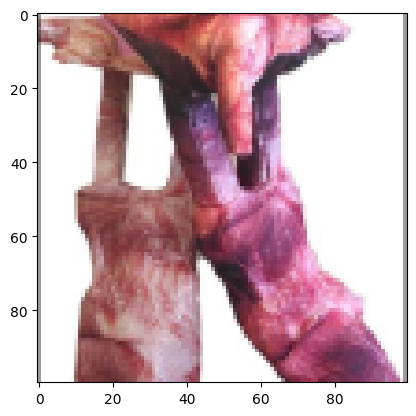

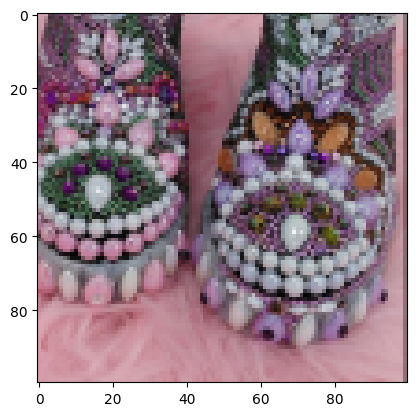

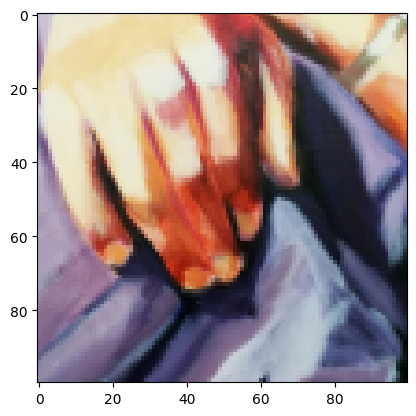

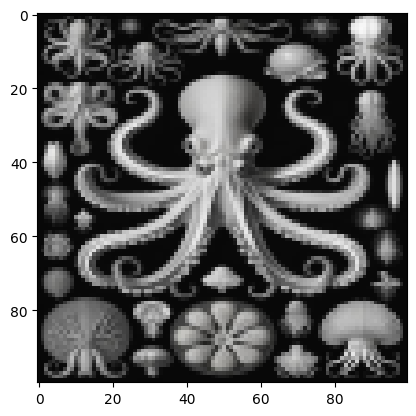

In [4]:
import cv2
for i,image in enumerate(images_to_display):
    plt.figure(3+i)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image[:,:,:3])
pools = []
for gene in genes:
    pools.append(utils.make_gene_pool(gene, height=HEIGHT, width=WIDTH, channels=CHANNELS, freq=freq, pool_size=200))
seeds = []
for pool in pools:
    seeds.append(pool[0].clone())

In [5]:
partitions = len(genes)
part_index = 0
diff = 1e6
if partitions == 1:
    part = [BATCH_SIZE]
elif (BATCH_SIZE % partitions) == 0:
    part = [BATCH_SIZE//partitions for _ in range(partitions)]
else:
    combs = [comb for comb in it.product(range(BATCH_SIZE), repeat=partitions) if sum(comb) == BATCH_SIZE]
    for idx,comb in enumerate(combs):
        sum = 0
        for id in range(len(comb)-1):
            for i in range(id+1,len(comb)):
                sum += abs(comb[id] - comb[i])
        if sum < diff:
            diff = sum
            part_index = idx

    part = combs[part_index]
print(part)

[3, 3, 3, 3]


In [6]:
loss_log=[]
nca = GeneCA(CHANNELS,256, gene_size=GENESIZE)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)

imgs = []
for i,p in enumerate(part):
    imgs.append(images[i].tile(p,1,1,1))

y = torch.cat(imgs, dim=0)

print(images[0].shape)
save_memory = True


torch.Size([4, 100, 100])


In [7]:
with torch.no_grad():
    vgg_losses = [utils.create_dino_loss(img_base[None,0:3,...]) for img_base in images]

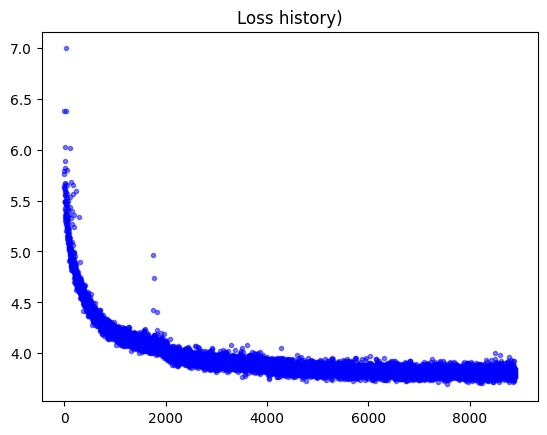

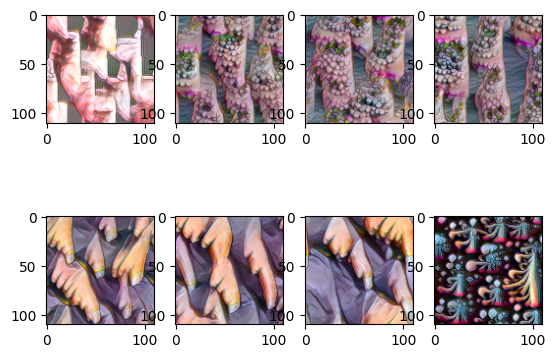

KeyboardInterrupt: 

In [8]:
for i in range(16000 + 1):
    loss = 0
    with torch.no_grad():
        seeds2 = []
        for seed in seeds:
            seed[:3] = utils.simple_rgb_perlin(1,HEIGHT, WIDTH, freq,DEVICE)
            seeds2.append(seed)
        seeds = seeds2
        idxs, x = utils.get_gene_pool(pools, part, seeds)
    #optim.zero_grad()
    losses = []
    itters = random.randint(32,64)
    outputs =[]

    if not save_memory:
        for j in range(itters):
            x = nca(x, 0.5)

    else:
        x.requires_grad = True  # https://github.com/pytorch/pytorch/issues/42812
        for j in range(itters):
            # Checkpoint the internal computations of each individual step
            x = torch.utils.checkpoint.checkpoint(nca, x, 0.5, use_reentrant=False)


    idx_cum = 0

    for id,vgg_loss in enumerate(vgg_losses):
        loss = loss + vgg_loss(x[idx_cum: idx_cum + part[id], 0:3,...]) + (x.clip(-1,1) - x).pow(2).mean()
        loss += utils.rgb_color_loss(y[idx_cum: idx_cum + part[id],:3],x[idx_cum: idx_cum + part[id],:3]) *10

        idx_cum += part[id]




    loss_log.append(loss.log().item() )
    with torch.no_grad():
        pools = utils.udate_gene_pool(pools, x.clone().detach(), idxs, part)
    optim.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(nca.parameters(), 1)
    optim.step()
    scheduler.step()
    x = x.detach()

    #loss = loss.detach()
    if i % 100 == 0:

        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1,figsize=(10, 4))
        plt.title('Loss history)')

        plt.plot(loss_log, '.', alpha=0.5, color = "b")
        utils.show_batch(x[2:10], channels=3)
        plt.show(block=False)
        plt.pause(0.01)
        torch.save(nca.state_dict(), "Trained_models/" + "art_4"+ ".pth")
